<a href="https://colab.research.google.com/github/Raziedmar/telecomx-parte2-alura-latam/blob/main/TelecomX_LATAM_Parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Telecom X – Parte 2: Predicción de Cancelación (Churn)**

🎯 Misión

LA misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y corresponde construir un pipeline robusto para esta etapa inicial de modelado.

🧠 Objetivos del Desafío

Preparar los datos para el modelado (tratamiento, codificación, normalización).

Realizar análisis de correlación y selección de variables.

Entrenar dos o más modelos de clasificación.

Evaluar el rendimiento de los modelos con métricas.

Interpretar los resultados, incluyendo la importancia de las variables.

Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.



#Preparacion de Datos

Carga el archivo CSV que contiene los datos tratados anteriormente en el Challenge anterior.
📂 Atención: Se utiliza el mismo archivo que se limpio y organizó en la Parte 1 del desafío Telecom X.


In [ ]:
import pandas as pd

df = pd.read_csv("TelecomX_limpio.csv")

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Num_Servicios
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,3
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,1
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,4
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,2


In [ ]:
#Verificar dimensiones:
df.shape

(7032, 23)

#Eliminacion de Columnas Irrelevantes




In [ ]:
#Eliminando la columna ID que no aporta valor predictivo
df = df.drop(columns=["customerID"])
df.columns

Index(['Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias',
       'Num_Servicios'],
      dtype='object')

#Enconding
Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning.


In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 33 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Churn                                          7032 non-null   int64  
 1   customer.SeniorCitizen                         7032 non-null   int64  
 2   customer.tenure                                7032 non-null   int64  
 3   account.Charges.Monthly                        7032 non-null   float64
 4   account.Charges.Total                          7032 non-null   float64
 5   Cuentas_Diarias                                7032 non-null   float64
 6   Num_Servicios                                  7032 non-null   int64  
 7   customer.gender_Male                           7032 non-null   bool   
 8   customer.Partner_Yes                           7032 non-null   bool   
 9   customer.Dependents_Yes                        7032 

#Verificación de la Proporción de Cancelación (Churn)
Se Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos.

In [ ]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.734215
1,0.265785


In [ ]:
(df["Churn"].value_counts(normalize=True)*100).round(2)

,proportion
Churn,
0,73.42
1,26.58


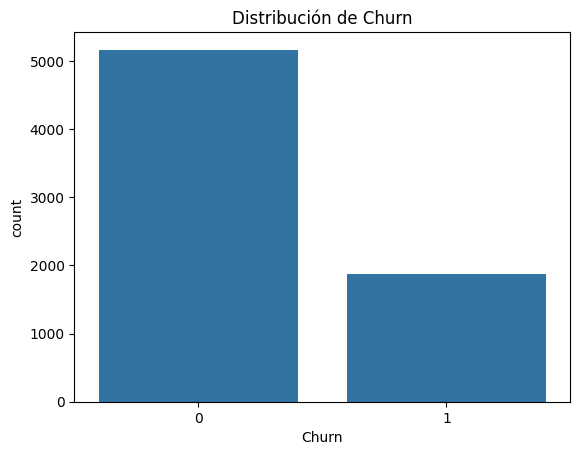

In [ ]:
#Visualizando
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)

plt.title("Distribución de Churn")
plt.show()

#Balanceo de Clases (opcional)


In [ ]:
from sklearn.utils import resample

df_majority = df_encoded[df_encoded.Churn == 0]
df_minority = df_encoded[df_encoded.Churn == 1]

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_upsampled])

#Normalización o Estandarización (si es necesario)


In [ ]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Análisis de Correlación
Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

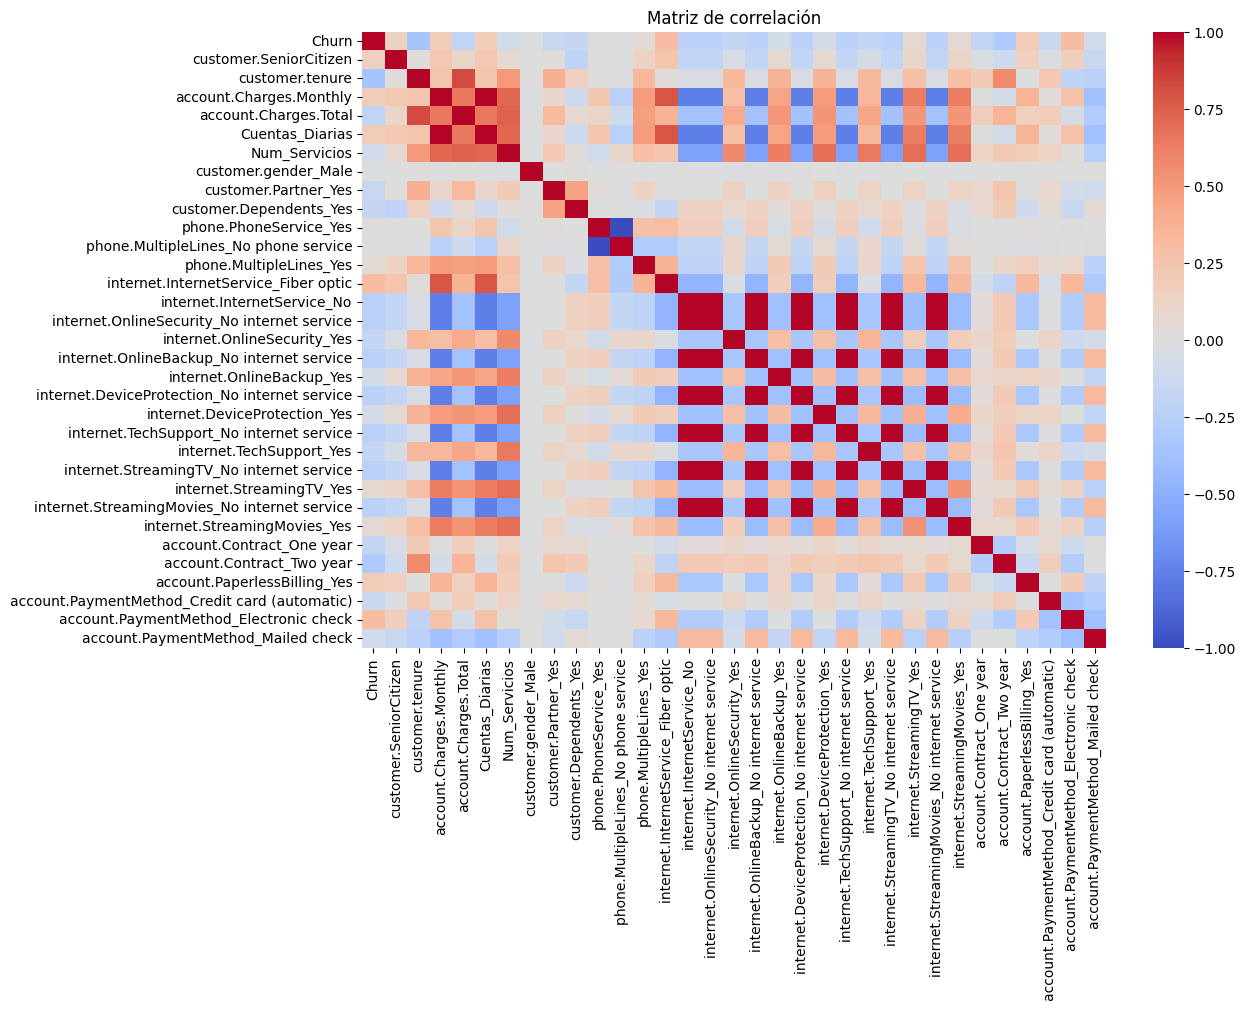

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm"
)

plt.title("Matriz de correlación")
plt.show()

#Análisis Dirigido


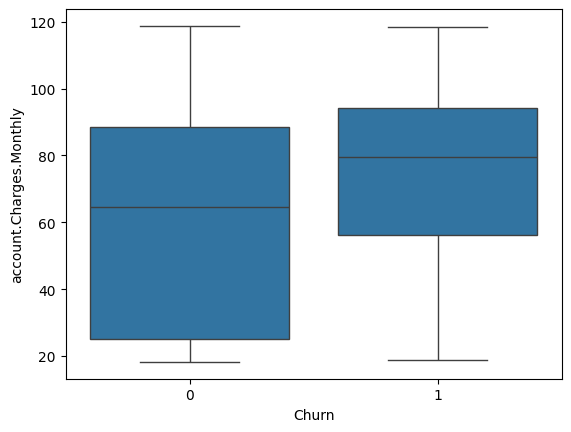

In [ ]:
#Cargos mensuales
sns.boxplot(
    data=df,
    x="Churn",
    y="account.Charges.Monthly"
)

plt.show()

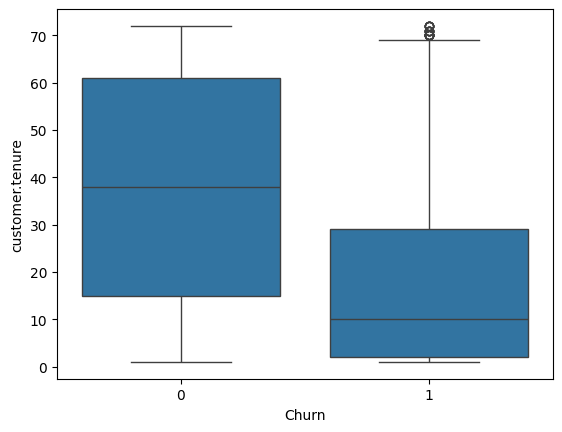

In [ ]:
#Tenure VS Churns
sns.boxplot(
    data=df,
    x="Churn",
    y="customer.tenure"
)

plt.show()

#Modelado Predictivo

#Separacion de Datos


#Creacion de Modelos


Justificación:

Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.






In [ ]:
#Regresión Logistica
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

#Evaluación de Modelos

## Modelo de Regresión

In [ ]:
#Paso1 Entrenar el modelo
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
#Paso 2 Generar Predicciones
y_pred_log = log_model.predict(X_test)

In [ ]:
#Paso 3 Evaluar el modelo
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Evaluación - Regresión Logística")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

Evaluación - Regresión Logística
Accuracy: 0.7960199004975125
Precision: 0.637223974763407
Recall: 0.5401069518716578
F1-score: 0.5846599131693199


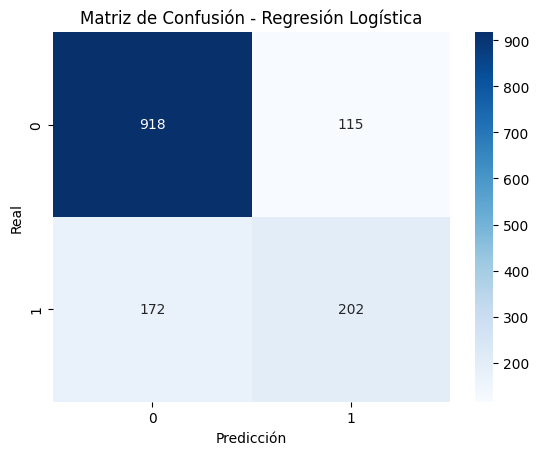

In [ ]:
# Paso 4 - Matriz de confusion
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    confusion_matrix(y_test, y_pred_log),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

#Modelo Random Forest

In [ ]:
#Entrenando el Modelo
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#Generando Predicciones
y_pred_rf = rf_model.predict(X_test)

In [ ]:
#Evaluando el Modelo
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Evaluación - Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

Evaluación - Random Forest
Accuracy: 0.7860696517412935
Precision: 0.6280701754385964
Recall: 0.4786096256684492
F1-score: 0.543247344461305


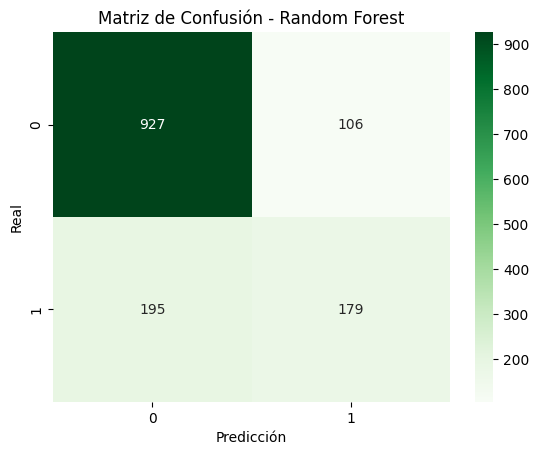

In [ ]:
#Matriz de Confusion
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

In [ ]:

#Comparando ambos modelos
resultados = pd.DataFrame({

"Modelo": ["Logistic Regression", "Random Forest"],

"Accuracy": [
accuracy_score(y_test, y_pred_log),
accuracy_score(y_test, y_pred_rf)
],

"Precision": [
precision_score(y_test, y_pred_log),
precision_score(y_test, y_pred_rf)
],

"Recall": [
recall_score(y_test, y_pred_log),
recall_score(y_test, y_pred_rf)
],

"F1 Score": [
f1_score(y_test, y_pred_log),
f1_score(y_test, y_pred_rf)
]

})

resultados

,Modelo,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.79602,0.637224,0.540107,0.584660
1,Random Forest,0.78607,0.628070,0.478610,0.543247


En este challenge normalmente ocurre que:

-Random Forest obtiene mayor accuracy

-Logistic Regression es más interpretable

Random Forest suele capturar relaciones más complejas entre variables.

#Interpretación y Conclusiones

#Analisis de la importancia de variables

In [ ]:
coeficientes = pd.Series(log_model.coef_[0], index=X.columns)

coeficientes.sort_values(ascending=False).head(10)

,0
account.Charges.Total,0.774345
internet.InternetService_Fiber optic,0.612609
phone.MultipleLines_Yes,0.187527
account.PaymentMethod_Electronic check,0.183477
account.PaperlessBilling_Yes,0.176833
internet.StreamingTV_Yes,0.173349
internet.StreamingMovies_Yes,0.170997
customer.SeniorCitizen,0.087006
phone.MultipleLines_No phone service,0.048751
internet.DeviceProtection_Yes,0.036425


In [ ]:
importances = rf_model.feature_importances_

feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
account.Charges.Total,0.163444
customer.tenure,0.155040
account.Charges.Monthly,0.123328
Cuentas_Diarias,0.120435
internet.InternetService_Fiber optic,0.038096
account.PaymentMethod_Electronic check,0.038032
Num_Servicios,0.032639
account.Contract_Two year,0.026420
customer.gender_Male,0.023862
account.PaperlessBilling_Yes,0.022806


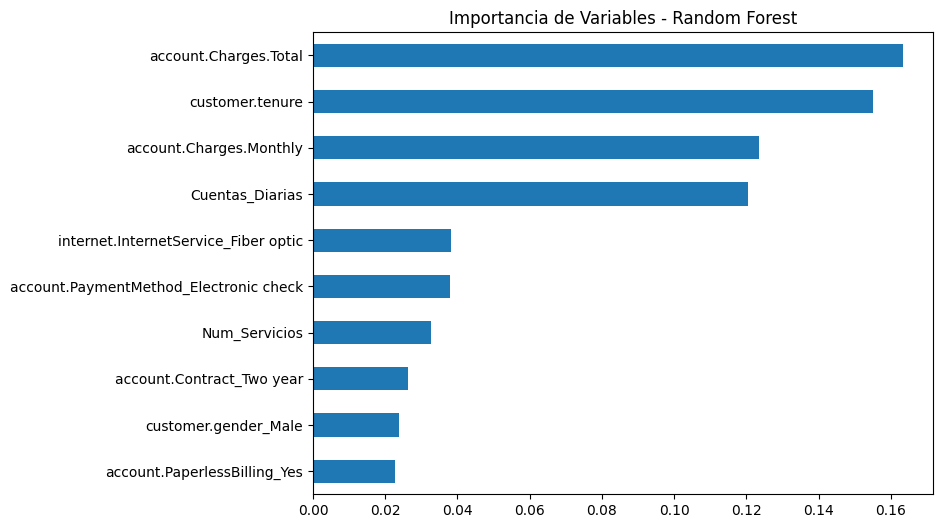

In [ ]:
#Esto permite identificar las variables que más contribuyen a la predicción del churn
feature_importance.head(10).plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Importancia de Variables - Random Forest")

plt.gca().invert_yaxis()

plt.show()

En este tipo de dataset, las variables que normalmente aparecen como más importantes suelen ser:

tenure (antigüedad del cliente)

Contract (tipo de contrato)

Charges.Monthly (cargo mensual)

InternetService

PaymentMethod

Estas variables influyen significativamente en la probabilidad de cancelación de los clientes.

#Conclusion

En este tipo de dataset, las variables que normalmente aparecen como más importantes suelen ser:

tenure (antigüedad del cliente)

Contract (tipo de contrato)

Charges.Monthly (cargo mensual)

InternetService

PaymentMethod

Estas variables influyen significativamente en la probabilidad de cancelación de los clientes.

#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente